# Tutorial 5: Selecting the number of topics

One of the key decisions when running mTopic is choosing the number of topics *K*, as it must be specified before the training begins. The standard approach is to train the model across several values of *K* and evaluate which best captures the underlying structure of your data. This tutorial introduces an automatic workflow for selecting the number of topics using held-out log-likelihood and cross-validation.

---

Throughout this tutorial, we use the Human Tonsil dataset. Keep in mind before you begincthat the input object must contain unprocessed counts. Preprocessing is applied internally during cross-validation, separately for each train/test split — do not normalize or transform the data beforehand.

In [1]:
! wget -O HumanTonsil_filtered.h5mu \
  "https://zenodo.org/records/20044694/files/HumanTonsil_filtered.h5mu?download=1"

--2026-05-06 19:58:34--  https://zenodo.org/records/20044694/files/HumanTonsil_filtered.h5mu?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 188.185.43.153, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18343969 (17M) [application/octet-stream]
Saving to: ‘HumanTonsil_filtered.h5mu’

HumanTonsil_filtere 100%[===================>]  17.49M  2.85MB/s    in 6.3s    

2026-05-06 19:58:55 (2.76 MB/s) - ‘HumanTonsil_filtered.h5mu’ saved [18343969/18343969]



In [2]:
import mtopic

mdata = mtopic.read.h5mu("HumanTonsil_filtered.h5mu")
mdata

MuData object with n_obs × n_vars = 4194 × 5025
  uns:	'CELLTYPE_COLOR', 'TOPIC_CELLTYPE', 'TOPIC_COLOR'
  obsm:	'coords'
  2 modalities
    rna:	4194 x 5000
    prot:	4194 x 25

## Running cross-validation

You can run cross-validation to estimate the number of topics with `mtopic.tl.select_n_topics`. The cells are randomly split into `n_folds` folds. For each fold, the model is trained on the remaining folds, and the learned topic structure is used to characterise the held-out cells. The quality of this characterisation is measured as a log-likelihood — how probable the held-out data is under the model. This is repeated for every value of *K* in the provided range. Set `is_spatial=True` for spatial datasets to evaluate sMTM instead of MTM.

Results are stored directly in `mdata`: per-fold scores in `mdata.uns["CV_results"]` and fold assignments in `mdata.obs["CV_split"]`.

In [3]:
mtopic.tl.select_n_topics(mdata, is_spatial=True, n_jobs=100)

mdata

[CV 1/5]
  K=5	LL=-91026725.43	t=99.6s
  K=20	LL=-90713726.23	t=85.9s
  K=40	LL=-90646090.54	t=130.0s
  K=60	LL=-90642637.90	t=136.5s
  K=80	LL=-90606376.09	t=147.6s
  K=100	LL=-90620322.06	t=173.6s
[CV 2/5]
  K=5	LL=-91100362.62	t=72.7s
  K=20	LL=-90729120.05	t=83.6s
  K=40	LL=-90665581.19	t=124.2s
  K=60	LL=-90653380.73	t=135.8s
  K=80	LL=-90626111.80	t=148.7s
  K=100	LL=-90636337.09	t=173.9s
[CV 3/5]
  K=5	LL=-91106016.93	t=73.1s
  K=20	LL=-90759045.79	t=80.6s
  K=40	LL=-90689924.91	t=123.0s
  K=60	LL=-90689185.89	t=134.8s
  K=80	LL=-90650532.50	t=148.5s
  K=100	LL=-90671487.12	t=172.3s
[CV 4/5]
  K=5	LL=-91043043.41	t=74.7s
  K=20	LL=-90714113.77	t=82.3s
  K=40	LL=-90652713.76	t=123.6s
  K=60	LL=-90643129.20	t=136.0s
  K=80	LL=-90607425.34	t=148.1s
  K=100	LL=-90618624.46	t=173.7s
[CV 5/5]
  K=5	LL=-90886780.00	t=74.5s
  K=20	LL=-90504830.00	t=82.2s
  K=40	LL=-90429070.49	t=124.3s
  K=60	LL=-90427087.91	t=137.3s
  K=80	LL=-90390399.27	t=149.2s
  K=100	LL=-90411502.93	t=173.3s


MuData object with n_obs × n_vars = 4194 × 5025
  obs:	'CV_split'
  uns:	'CELLTYPE_COLOR', 'TOPIC_CELLTYPE', 'TOPIC_COLOR', 'CV_results'
  obsm:	'coords'
  2 modalities
    rna:	4194 x 5000
    prot:	4194 x 25

## Identifying the optimal *K*

Visualize the results with `mtopic.pl.select_n_topics`. The held-out log-likelihood increases with *K* — adding more topics always improves the score to some degree. Because the curve never turns down, we cannot simply pick the maximum. Instead, we look for the point of diminishing returns: the value of *K* beyond which additional topics bring only marginal improvement. To find this point automatically, a rational function is fitted to the curve and the onset of the plateau is identified as the point where the slope drops to 5% of its peak value. The suggested *K* is shown on the plot and stored in `mdata.uns["CV_fit_info"]`.

Treat the computed optimal K as a guideline, feel free to select more/fewer topics if you expect more/less granularity.

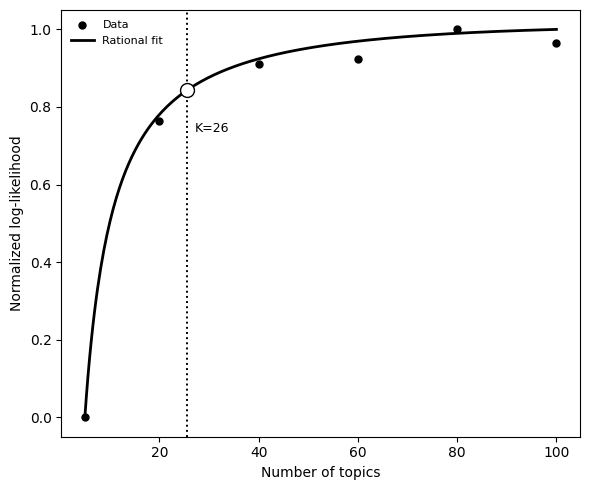

In [4]:
mtopic.pl.select_n_topics(mdata)

Here, the recommended number of topics, based on held-out log-likelihood, is 26.

## Conclusions

Cross-validation gives a principled, data-driven estimate of *K*, but it is expensive. Running a full grid of candidate values of *K* with multiple folds means fitting a lot of models per dataset — which can take some time depending on dataset size. The recommended *K* should be treated as a suggestion rather than a hard answer. For routine use, we recommend a lighter approach: train full models at a small set of values such as *K* = 20, 30, 50 and pick the one at which the topics best match the granularity you need — do they correspond to known cell types, tissue compartments, or regulatory programmes?